# Semana 5 — Análisis del dataset original (Reconocimiento inicial)

**Materia:** Minería de Datos  
**Tema:** Limpieza y Transformación de Datos  

El estado inicial del dataset antes de aplicar limpieza y transformaciones.

En esta etapa se revisa:

- Dataset original.
- Tipos de datos.
- Valores nulos.
- Estadísticas descriptivas.
- Detección inicial de outliers en `Ingresos` usando IQR.
- Estado de las variables categóricas antes de codificarlas.

## 1. Importación de librerías

Usamos `pandas` para crear y analizar el dataset, y `seaborn`/`matplotlib` para visualizar los datos.

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración general para que los gráficos se vean mejor
sns.set_theme(style="whitegrid")


## 2. Creación del dataset original

El contexto es una empresa de análisis financiero que trabaja con datos de clientes bancarios. El objetivo final será preparar estos datos para un posible modelo de predicción de solvencia financiera.

Cargam de los datos originales.

In [24]:
df = pd.DataFrame({
    "Cliente": [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad": [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos": [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Historial_Pagos": ["Bueno", "Regular", "Malo", "Bueno", "Regular", "Malo", "Bueno", "Regular"],
    "Categoría": ["A", "B", "C", "A", "B", "C", "A", "B"]
})

df

,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B
5,6,45,85000,Malo,C
6,7,38,72000,Bueno,A
7,8,29,48000,Regular,B


## 3. Revisión general del dataset

Primero revisamos cuántas filas y columnas tiene el dataset, qué tipos de datos contiene y si las columnas están correctamente cargadas.

In [36]:
print("Cantidad de filas y columnas:")
print(df.shape)

print("Tipos de datos:")
print(df.dtypes)

print("Información general del dataset:")
df.info()


Cantidad de filas y columnas:
(8, 5)
Tipos de datos:
Cliente             int64
Edad                int64
Ingresos            int64
Historial_Pagos    object
Categoría          object
dtype: object
Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Cliente          8 non-null      int64 
 1   Edad             8 non-null      int64 
 2   Ingresos         8 non-null      int64 
 3   Historial_Pagos  8 non-null      object
 4   Categoría        8 non-null      object
dtypes: int64(3), object(2)
memory usage: 452.0+ bytes


### Interpretación

El dataset tiene **8 clientes** y **5 columnas**.

- `Cliente`: identificador numérico del cliente.
- `Edad`: variable numérica.
- `Ingresos`: variable numérica.
- `Historial_Pagos`: variable categórica.
- `Categoría`: variable categórica.

En esta etapa todavía no se codifican las variables categóricas porque estamos mostrando el estado inicial del dataset.

## 4. Revisión de valores nulos

Los valores nulos son datos faltantes. 

En una actividad de limpieza, este paso es necesario porque los valores faltantes pueden afectar análisis posteriores.

In [37]:
valores_nulos = df.isnull().sum()
valores_nulos


Cliente            0
Edad               0
Ingresos           0
Historial_Pagos    0
Categoría          0
dtype: int64

### Interpretación

En el dataset original **no se observan valores nulos** en `Edad` ni en `Ingresos`, ni tampoco en las columnas categóricas.

## 5. Estadísticas descriptivas de las variables numéricas

Se analiza las variables `Edad` e `Ingresos` para conocer sus valores mínimos, máximos, promedio y dispersión.

In [27]:
df[["Edad", "Ingresos"]].describe()


,Edad,Ingresos
count,8.000000,8.000000
mean,36.500000,63750.000000
std,8.468429,15238.578861
min,25.000000,45000.000000
25%,29.750000,49500.000000
50%,36.500000,65000.000000
75%,41.250000,74000.000000
max,50.000000,85000.000000


### Interpretación

Este resumen permite observar el comportamiento inicial de las variables numéricas:

- `Edad`: muestra la edad mínima, máxima y promedio de los clientes.
- `Ingresos`: muestra el rango inicial de ingresos antes de normalizar.

Estos valores todavía están en su escala original.

## 6. Visualización inicial de Edad e Ingresos

Distribución inicial para observación de los datos antes de realizar transformaciones.

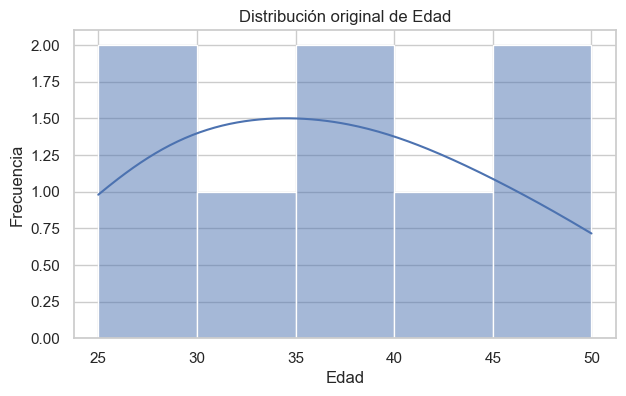

In [28]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Edad"], bins=5, kde=True)
plt.title("Distribución original de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


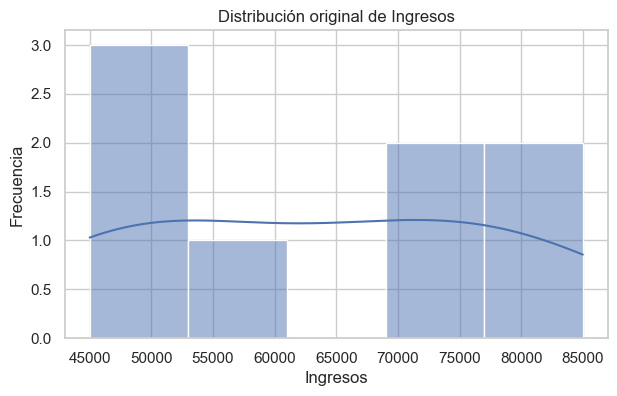

In [29]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Ingresos"], bins=5, kde=True)
plt.title("Distribución original de Ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.show()


### Interpretación

Los histogramas muestran cómo se distribuyen las edades y los ingresos antes de modificar los datos.

En esta instancia, los ingresos todavía están expresados en valores monetarios originales, luego se realizará la normalización para llevarlos a una escala común.

## 7. Detección inicial de outliers en Ingresos con IQR

La actividad pide detectar outliers en `Ingresos` usando el método IQR.

El método IQR calcula:

- `Q1`: primer cuartil.
- `Q3`: tercer cuartil.
- `IQR = Q3 - Q1`.
- Límite inferior: `Q1 - 1.5 * IQR`.
- Límite superior: `Q3 + 1.5 * IQR`.

Los valores fuera de esos límites se consideran posibles outliers.

In [30]:
Q1 = df["Ingresos"].quantile(0.25)
Q3 = df["Ingresos"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)


Q1: 49500.0
Q3: 74000.0
IQR: 24500.0
Límite inferior: 12750.0
Límite superior: 110750.0


In [31]:
outliers_ingresos = df[(df["Ingresos"] < limite_inferior) | (df["Ingresos"] > limite_superior)]

print("Cantidad de outliers detectados en Ingresos:", len(outliers_ingresos))
outliers_ingresos


Cantidad de outliers detectados en Ingresos: 0


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría


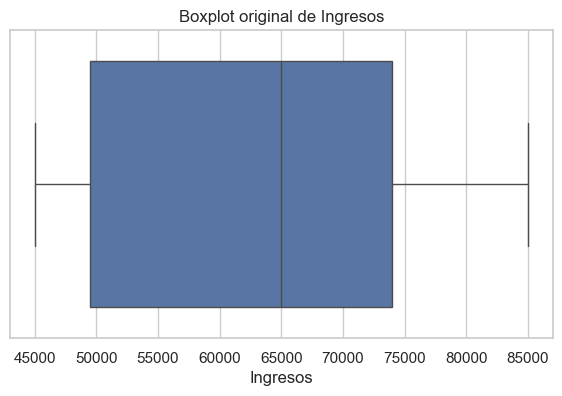

In [32]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df["Ingresos"])
plt.title("Boxplot original de Ingresos")
plt.xlabel("Ingresos")
plt.show()


### Interpretación

Aplicando el método IQR sobre la columna `Ingresos`, no se detectan valores por debajo del límite inferior ni por encima del límite superior.

Por lo tanto, para este dataset inicial, **no hay outliers evidentes en Ingresos**.

## 8. Revisión de variables categóricas antes de transformar

Las variables categóricas contienen texto. Para usarlas en modelos de Machine Learning, luego deberán transformarse a valores numéricos.

In [33]:
print("Frecuencia de Historial_Pagos:")
print(df["Historial_Pagos"].value_counts())

print("Frecuencia de Categoría:")
print(df["Categoría"].value_counts())


Frecuencia de Historial_Pagos:
Historial_Pagos
Bueno      3
Regular    3
Malo       2
Name: count, dtype: int64
Frecuencia de Categoría:
Categoría
A    3
B    3
C    2
Name: count, dtype: int64


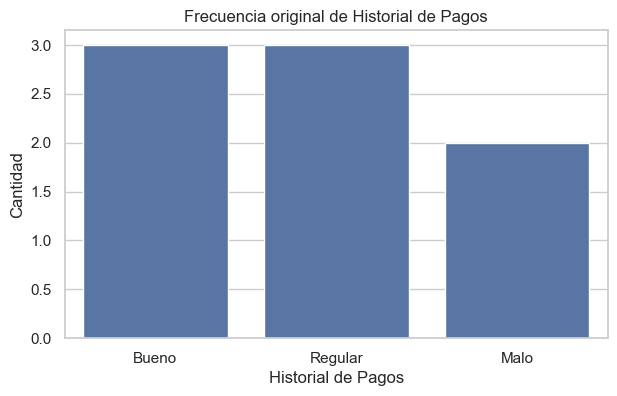

In [34]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Historial_Pagos")
plt.title("Frecuencia original de Historial de Pagos")
plt.xlabel("Historial de Pagos")
plt.ylabel("Cantidad")
plt.show()


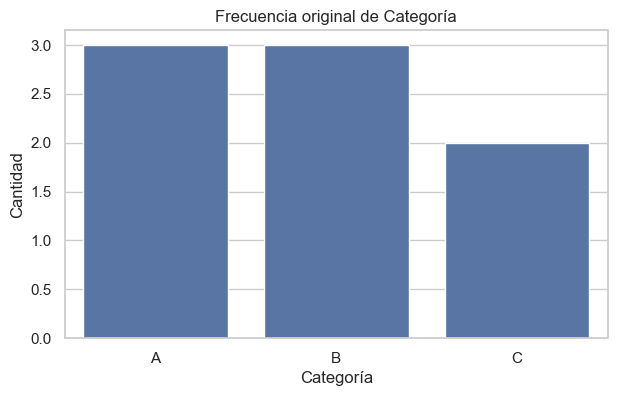

In [35]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Categoría")
plt.title("Frecuencia original de Categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.show()


### Interpretación

`Historial_Pagos` tiene tres valores posibles: `Bueno`, `Regular` y `Malo`.

`Categoría` tiene tres valores posibles: `A`, `B` y `C`.

En el "Notebook Procesado" se aplicarán las transformaciones solicitadas:

- One-Hot Encoding para `Historial_Pagos`.
- Label Encoding para `Categoría`.

## 9. Conclusión del análisis inicial

En esta primera etapa se revisó el dataset antes de aplicar limpieza y transformación.

Conclusiones principales:

1. El dataset tiene 8 registros y 5 columnas.
2. No se detectaron valores nulos.
3. No se detectaron outliers en `Ingresos` usando el método IQR.
4. `Edad` e `Ingresos` están en su escala original.
5. `Historial_Pagos` y `Categoría` siguen siendo variables categóricas de texto.
6. El dataset está listo para pasar a la etapa de transformación.

En el siguiente notebook se aplican los criterios solicitados para cumplir con la actividad: normalización, estandarización y codificación de variables categóricas.